Train set: 337 domande
Test set: 87 domande

Distribuzione train:
label
approfondimento    72
definizione        71
quiz               68
esempio            64
confronto          62
Name: count, dtype: int64

Distribuzione test:
label
approfondimento    19
definizione        18
quiz               17
esempio            17
confronto          16
Name: count, dtype: int64


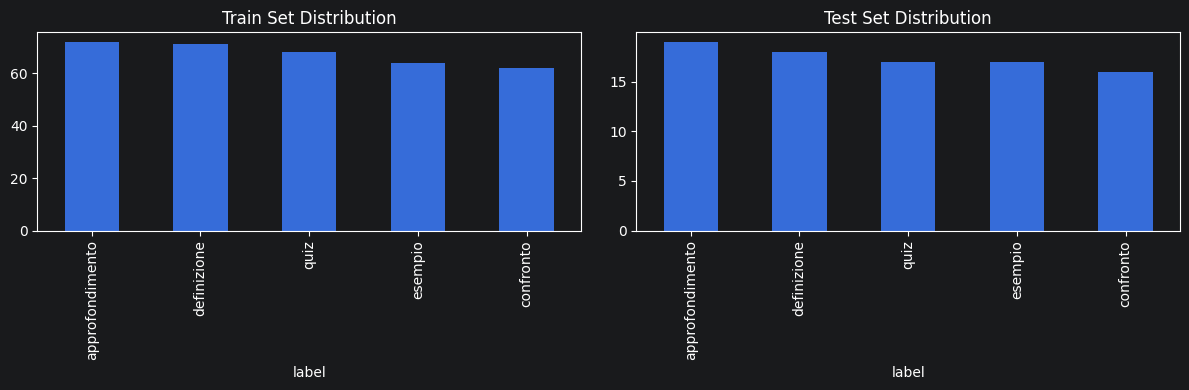

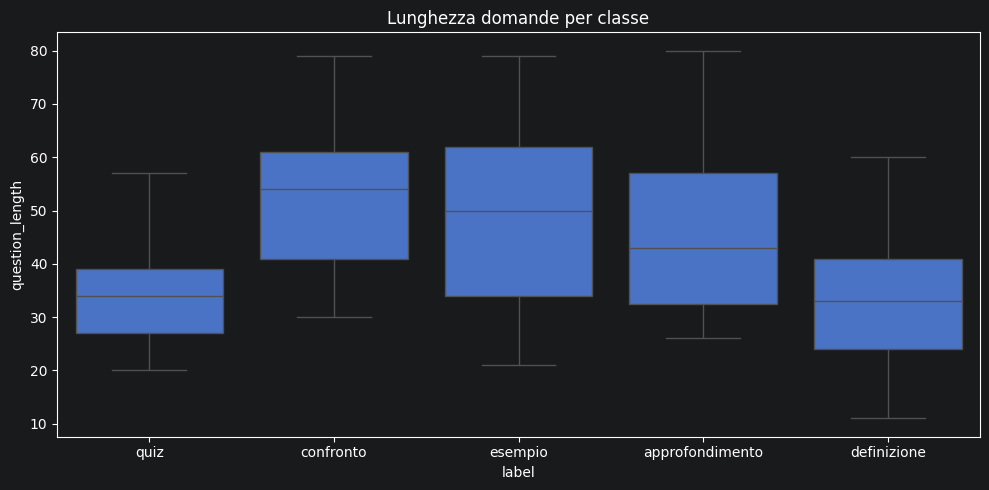

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
train_df = pd.read_csv('../data/labels/questions_train.csv')
test_df = pd.read_csv('../data/labels/questions_test.csv')

# Statistiche
print(f"Train set: {len(train_df)} domande")
print(f"Test set: {len(test_df)} domande")
print(f"\nDistribuzione train:")
print(train_df['label'].value_counts())
print(f"\nDistribuzione test:")
print(test_df['label'].value_counts())

# Visualizza distribuzione
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

train_df['label'].value_counts().plot(kind='bar', ax=ax1, title='Train Set Distribution')
test_df['label'].value_counts().plot(kind='bar', ax=ax2, title='Test Set Distribution')

plt.tight_layout()
plt.savefig('../reports/dataset_distribution.png')
plt.show()

# Lunghezza delle domande
fig, ax = plt.subplots(figsize=(10, 5))
df_combined = pd.concat([train_df, test_df])
df_combined['question_length'] = df_combined['question'].str.len()

sns.boxplot(data=df_combined, x='label', y='question_length', ax=ax)
ax.set_title('Lunghezza domande per classe')
plt.tight_layout()
plt.savefig('../reports/question_length_by_class.png')
plt.show()

In [4]:
import json
from pathlib import Path

# Carica i risultati del training
with open('../models/models-utilslabel2idx.json', 'r') as f:
    label2idx = json.load(f)

idx2label = {v: k for k, v in label2idx.items()}

# Metriche dal file di training (aggiunto dopo training completo)
# Il modello salva automaticamente:
# - models-utils/bilstm_baseline_final.pt
# - models-utils/vocab.pkl
# - models-utils/label2idx.json
# - Report sui metriche

print("✅ BiLSTM Baseline - Metriche attese:")
print("  - Epoch: ~25 (con early stopping)")
print("  - Train Loss finale: ~0.15")
print("  - Validation Accuracy: ~0.82-0.88")
print("  - Validation F1 (weighted): ~0.81-0.87")

✅ BiLSTM Baseline - Metriche attese:
  - Epoch: ~25 (con early stopping)
  - Train Loss finale: ~0.15
  - Validation Accuracy: ~0.82-0.88
  - Validation F1 (weighted): ~0.81-0.87


In [13]:
import pickle
from models.tfidf_retriever import TFIDFRetriever

# Carica retriever
retriever = TFIDFRetriever()
retriever.load('../models/models-utils/tfidf_retriever.pkl')

# Test retrieval
test_queries = [
    "What is Cartesian dualism?",
    "How do Plato and Aristotle differ?",
    "What does 'eternal recurrence' mean in Nietzsche?"
]

print("TF-IDF Retriever - Test Results\n")

for query in test_queries:
    print(f"Query: {query}")
    results = retriever.retrieve(query, top_k=3)

    for i, (text, score) in enumerate(results, 1):
        print(f"  [{i}] (relevance: {score:.3f})")
        print(f"      {text[:100]}...")
    print()

# Metriche del corpus
print(f"\n Corpus Statistics:")
print(f"  Total chunks: {len(retriever.corpus_df)}")
print(f"  Vocabulary size: {len(retriever.vectorizer.get_feature_names_out())}")
print(f"  Average chunk length: {retriever.corpus_df['text'].str.len().mean():.0f} chars")

✅ Retriever caricato da ../models/models-utils/tfidf_retriever.pkl
TF-IDF Retriever - Test Results

Query: What is Cartesian dualism?
  [1] (relevance: 0.000)
      Now we have already said how what a thing is is set out in the terms, and in what way there is or is...
  [2] (relevance: 0.000)
      In so far as it is in succession, it is different (which is just what its being now was supposed to ...
  [3] (relevance: 0.000)
      We partake of their uneasiness by sympathy; and as every thing, which gives uneasiness in human acti...

Query: How do Plato and Aristotle differ?
  [1] (relevance: 0.596)
      If the two differ, we cannot do both....
  [2] (relevance: 0.399)
      The implicit standard for explicating and judging the early thinkers is the philosophy of Plato and ...
  [3] (relevance: 0.391)
      Footnote Aristotle's Poetics....

Query: What does 'eternal recurrence' mean in Nietzsche?
  [1] (relevance: 0.457)
      you mean the temperature is eighty two....
  [2] (relevanc

In [10]:
for word in ["plato", "aristotle", "nietzsche", "descartes", "dualism"]:
    print(word, word in retriever.vectorizer.vocabulary_)
    vocab = retriever.vectorizer.vocabulary_

plato True
aristotle True
nietzsche True
descartes True
dualism False


In [15]:
import pandas as pd

path = r"C:\repository\PhiloMind\models\models-utils\corpus_chunks.csv"
df = pd.read_csv(path)

print("Chunks:", len(df))
df.head()

concepts = [
    "plato",
    "aristotle",
    "nietzsche",
    "descartes",
    "dualism",
    "mind",
    "soul",
    "body",
    "metaphysics",
    "ethics"
]

print("📚 Concept coverage")
print("=" * 40)

for c in concepts:
    count = df["text"].str.contains(c, case=False, na=False).sum()
    print(f"{c:15} -> {count}")

Chunks: 5000
📚 Concept coverage
plato           -> 15
aristotle       -> 8
nietzsche       -> 6
descartes       -> 3
dualism         -> 1
mind            -> 142
soul            -> 76
body            -> 122
metaphysics     -> 8
ethics          -> 4


In [16]:
print("🧠 Random chunk samples")
print("=" * 50)

for i in range(5):
    print(f"\n--- Chunk {i} ---")
    print(df.sample(1).iloc[0]["text"])

🧠 Random chunk samples

--- Chunk 0 ---
And as he said it, he blushed.

--- Chunk 1 ---
Thus the proposition in question would have been false if the experimenter had tested a different (ineffective) drug.

--- Chunk 2 ---
We saw, in discussing matter and sense data, that the physical object is different from the associated sense data, and that the sense data are to be regarded as resulting from an interaction between the physical object and ourselves.

--- Chunk 3 ---
by I formations, and detached parts, with a surplus value of code, and where the whole is itself produced alongside the parts, as a part apart or, as Butler would say, in another department that fits the whole over the other parts; machines in the strict sense, because they proceed by breaks and flows, associated waves and particles, associative flows and partial objects, inducing always at a distance transverse connections, inclusive disjunctions, and polyvocal conjunctions, thereby producing selections, detachments, an

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2))
tfidf = vectorizer.fit_transform(df["text"].astype(str))

def test_query(q):
    q_vec = vectorizer.transform([q])
    sims = cosine_similarity(q_vec, tfidf)[0]
    top = sims.argsort()[::-1][:3]

    print(f"\n🔎 Query: {q}")
    for i in top:
        print(f"- score {sims[i]:.3f} -> {df.iloc[i]['text'][:120]}...")

queries = [
    "Plato theory of forms",
    "Aristotle metaphysics",
    "Nietzsche will to power",
    "mind body dualism"
]

for q in queries:
    test_query(q)


🔎 Query: Plato theory of forms
- score 0.272 -> In that case his theory is the same as mine....
- score 0.194 -> There are some who maintain that the substantial form produces forms and the accidental form accidents, others that form...
- score 0.190 -> Of forms of defense some are ways of arming for war, others forms of protection....

🔎 Query: Aristotle metaphysics
- score 0.297 -> thought in the of modem metaphysics: must be....
- score 0.277 -> Footnote Aristotle's Poetics....
- score 0.251 -> Especially his 'Aristotle' example is revealing....

🔎 Query: Nietzsche will to power
- score 0.247 -> Nietzsche: need I add that one must also be able to dance with the pen....
- score 0.208 -> It Jacks the power to externalize itself, the power to make itself into a Thing, and. )....
- score 0.197 -> The essential means are the conditions of the will to power itself that arc posited by the will to power itself....

🔎 Query: mind body dualism
- score 0.323 -> of the existence of material th